# Redlining in the Bay Area

## Exploration and processing of data

### Importing libraries and data

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches
from src.holc_utils import *

sns.set(style="whitegrid", context="notebook")
sns.set_palette('rocket')
fig_folder = "figures/redlining_bay_area/"

We are now importing the main dataset we obtained from [Mapping Inequality](https://dsl.richmond.edu/panorama/redlining/data) (< this is a url), and processed in the script `data_preprocessing.py`.

In [2]:
# loading HOLC data
holc = get_data_file("data/holc_bayarea.json")
holc.head()

,area_id,city,state,city_survey,category,grade,label,residential,commercial,industrial,...,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,6690,Oakland,CA,True,Best,A,A,True,False,False,...,0500000US06001,06001,Alameda,Alameda County,CA,California,06,1.910010e+09,216909647.0,"MULTIPOLYGON (((-122.20252 37.81099, -122.2021..."
1,6690,Oakland,CA,True,Best,A,A,True,False,False,...,0500000US06013,06013,Contra Costa,Contra Costa County,CA,California,06,1.856756e+09,225361409.0,"MULTIPOLYGON (((-122.20252 37.81099, -122.2021..."
2,6662,Oakland,CA,True,Best,A,A1,True,False,False,...,0500000US06001,06001,Alameda,Alameda County,CA,California,06,1.910010e+09,216909647.0,"MULTIPOLYGON (((-122.25734 37.89463, -122.2580..."
3,6662,Oakland,CA,True,Best,A,A1,True,False,False,...,0500000US06013,06013,Contra Costa,Contra Costa County,CA,California,06,1.856756e+09,225361409.0,"MULTIPOLYGON (((-122.25734 37.89463, -122.2580..."
4,6710,Oakland,CA,True,Best,A,A10,True,False,False,...,0500000US06001,06001,Alameda,Alameda County,CA,California,06,1.910010e+09,216909647.0,"MULTIPOLYGON (((-122.23403 37.80671, -122.2350..."


In order for us to map the geographic data, we will also require Bay Area's counties outline.

In [3]:
# make sure we have the same coordinate reference system (crs)
correct_crs = holc.crs
# get bay outline
bay_outline = get_bay_counties(correct_crs)

In [4]:
holc.columns

Index(['area_id', 'city', 'state', 'city_survey', 'category', 'grade', 'label',
       'residential', 'commercial', 'industrial', 'fill', 'STATEFP',
       'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD',
       'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry'],
      dtype='object')

Since we are going to work with the grades of areas, we need to get to know possible missing values or errors in our data. First we'll explore if there are areas without a grade assigned.

In [5]:
print(f"Grades assigned:\n{holc.grade.unique()}")
print(f"Categories assigned:\n{holc.category.unique()}")

Grades assigned:
['A' 'B' 'C' 'D' None]
Categories assigned:
['Best' 'Still Desirable' 'Definitely Declining' 'Hazardous'
 'Industrial and Commercial ' 'Industrial' 'Commercial']


As we can see, there are 5 possible values in the "grade" column, including `None`, let's see what is happening to those with `None` assigned.

In [6]:
holc[holc["grade"].isna()]

,area_id,city,state,city_survey,category,grade,label,residential,commercial,industrial,...,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
127,11172,Oakland,CA,True,Industrial and Commercial,None,Industrial and Commercial,False,True,True,...,0500000US06001,06001,Alameda,Alameda County,CA,California,06,1.910010e+09,216909647.0,"MULTIPOLYGON (((-122.15608 37.72594, -122.1573..."
229,11138,San Francisco,CA,True,Industrial and Commercial,None,Industrial and Commercial,False,True,True,...,0500000US06081,06081,San Mateo,San Mateo County,CA,California,06,1.161921e+09,757163219.0,"MULTIPOLYGON (((-122.39492 37.72951, -122.3951..."
230,11138,San Francisco,CA,True,Industrial and Commercial,None,Industrial and Commercial,False,True,True,...,0500000US06075,06075,San Francisco,San Francisco County,CA,California,06,1.209135e+08,479701988.0,"MULTIPOLYGON (((-122.39492 37.72951, -122.3951..."
268,11149,San Jose,CA,True,Industrial,None,Industrial,False,False,True,...,0500000US06085,06085,Santa Clara,Santa Clara County,CA,California,06,3.343891e+09,33597067.0,"MULTIPOLYGON (((-121.87293 37.31664, -121.8751..."
269,11150,San Jose,CA,True,Commercial,None,Commercial,False,True,False,...,0500000US06085,06085,Santa Clara,Santa Clara County,CA,California,06,3.343891e+09,33597067.0,"MULTIPOLYGON (((-121.89659 37.30408, -121.8975..."


As we can see, there are only 5 rows with a `None` grade, which also matches those that are categorized as commercial and/or industrial areas, just to make sure it is a 1:1 relationship, let's see if there are industrial and/or commercial areas that do have a grade assigned to them.

In [7]:
holc[(holc["commercial"]) | (holc["industrial"])]

,area_id,city,state,city_survey,category,grade,label,residential,commercial,industrial,...,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
127,11172,Oakland,CA,True,Industrial and Commercial,None,Industrial and Commercial,False,True,True,...,0500000US06001,06001,Alameda,Alameda County,CA,California,06,1.910010e+09,216909647.0,"MULTIPOLYGON (((-122.15608 37.72594, -122.1573..."
229,11138,San Francisco,CA,True,Industrial and Commercial,None,Industrial and Commercial,False,True,True,...,0500000US06081,06081,San Mateo,San Mateo County,CA,California,06,1.161921e+09,757163219.0,"MULTIPOLYGON (((-122.39492 37.72951, -122.3951..."
230,11138,San Francisco,CA,True,Industrial and Commercial,None,Industrial and Commercial,False,True,True,...,0500000US06075,06075,San Francisco,San Francisco County,CA,California,06,1.209135e+08,479701988.0,"MULTIPOLYGON (((-122.39492 37.72951, -122.3951..."
268,11149,San Jose,CA,True,Industrial,None,Industrial,False,False,True,...,0500000US06085,06085,Santa Clara,Santa Clara County,CA,California,06,3.343891e+09,33597067.0,"MULTIPOLYGON (((-121.87293 37.31664, -121.8751..."
269,11150,San Jose,CA,True,Commercial,None,Commercial,False,True,False,...,0500000US06085,06085,Santa Clara,Santa Clara County,CA,California,06,3.343891e+09,33597067.0,"MULTIPOLYGON (((-121.89659 37.30408, -121.8975..."


As we can see, those are the same 5 columns as before, so we are now sure that only the commercial and/or industrial categories are the only ones without a grade assigned. Since we are interested in the dataset as a whole, we deem valuable to keep those rows, but we will modify the grade value so that we can work with it later. 

We are also going to make an additional column combining category and grades, since they are closely related, and it would give us a better understanding of the historical perspectives.

In [8]:
# unify commercial/industrial category
conditions = [(holc["category"] == 'Industrial and Commercial ')|
              (holc["category"] == 'Industrial')|
              (holc["category"] == 'Commercial')]

choices = ['Commercial and/or Industrial']
holc["category"] = np.select(conditions, choices,default=holc["category"])

# imputing values
holc['grade'] = holc['grade'].fillna("Comm/Ind")
# adding grade-category column
holc["grade_category"] = holc["grade"] + " - " + holc["category"]


Lastly we will add an area column, for each of the polygons that we have in our geometries, so that we can use area as another aspect of our analysis.

In [9]:
# convert data to a projection usable to calculate areas
holc["area_km2"] = holc.to_crs(epsg=3857).area / 1e6

### Analysis

In this section we will try to answer the following questions:
1. How many HOLC-graded areas exist in the Bay Area?
2. What distribution of areas were graded A, B, C, and D?
3. How much land area was assigned each HOLC grade?
4. Were certain grades more geographically extensive?

All of these while comparing across cities.

But first, to be able to plot according to the colors on the data set, we will extract them and store them in a dictionary.

In [10]:
grade_color_map = (holc[["grade_category", "fill"]].drop_duplicates().set_index("grade_category")["fill"].to_dict())
grade_color_map

{'A - Best': '#76a865',
 'B - Still Desirable': '#7cb5bd',
 'C - Definitely Declining': '#ffff00',
 'D - Hazardous': '#d9838d',
 'Comm/Ind - Commercial and/or Industrial': '#000000'}

#### Question 1: How many HOLC-graded areas exist in the Bay Area?

In [11]:
# subsetting data - grouping by cities and counties
print(holc.groupby(["city","NAMELSAD"]).size().reset_index(name="count_holc_areas"))
city_counts = holc.groupby(["city"]).size().reset_index(name="count_holc_areas")

            city              NAMELSAD  count_holc_areas
0        Oakland        Alameda County               120
1        Oakland   Contra Costa County                 8
2  San Francisco  San Francisco County                98
3  San Francisco      San Mateo County                 5
4       San Jose    Santa Clara County                39


From the table before, the only cities that we have in our dataset are Oakland, San Francisco and San Jose. However, probably due to the old mapping of land we can find both Oakland and San Francisco in two different counties each. This is just something to take note of but in reality we won't use that level of disaggregation, we just need the count per city. Let's take a look at the map.

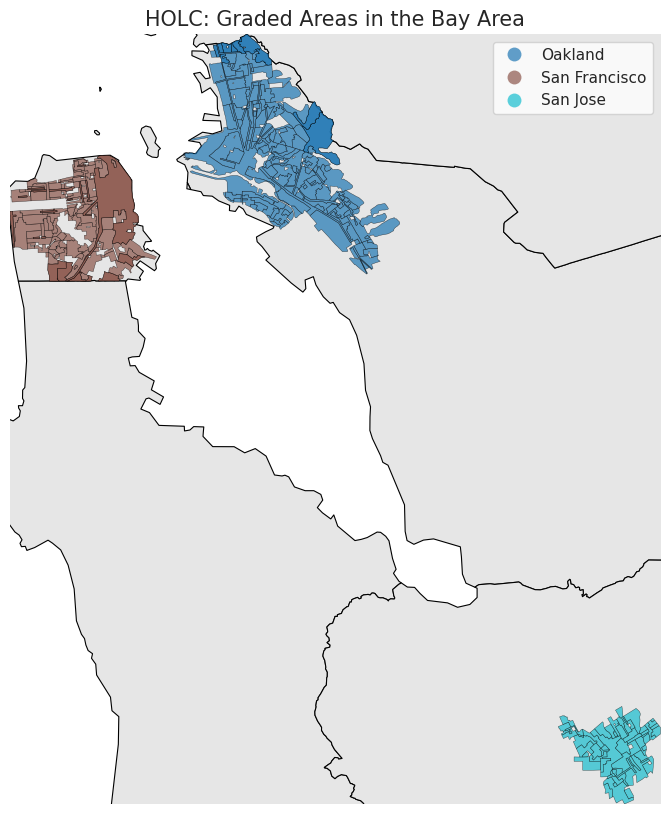

In [12]:
fig_name_holc_graded = "1_holc_graded_areas.png"

fig, ax = plt.subplots(figsize=(10, 10))

# Bay area counties outline
bay_outline.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="black",
    linewidth=0.8,
    alpha=1.0
)

# plot polygons of dataset
holc.plot(
    ax=ax,
    column="city",
    categorical=True,
    legend=True,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

# bound map limits to the polygons we have
ax.set_xlim(holc.total_bounds[0], holc.total_bounds[2])
ax.set_ylim(holc.total_bounds[1], holc.total_bounds[3])

ax.set_title("HOLC: Graded Areas in the Bay Area", fontsize=15)
ax.set_axis_off()

fig.savefig(fig_folder + fig_name_holc_graded)
plt.show()

Now let's see how those graded cities are disaggregated to the level of grade/commercial or industrial category.

In [13]:
# aggregate data by city and grade (include grade+category for labeling)
grade_counts = holc.groupby(["city","grade","grade_category"]).size().reset_index(name="count_graded_areas")
# adding the count of total holc areas for that city, for clarity
grade_counts = grade_counts.merge(city_counts, on=["city"], how="left")
# selecting important columns
grade_counts = grade_counts[["city","grade","grade_category","count_graded_areas","count_holc_areas"]]
# get relative count of grades
grade_counts["relative_count"] = round(grade_counts["count_graded_areas"] / grade_counts["count_holc_areas"],2)*100
print(grade_counts)

             city     grade                           grade_category  \
0         Oakland         A                                 A - Best   
1         Oakland         B                      B - Still Desirable   
2         Oakland         C                 C - Definitely Declining   
3         Oakland  Comm/Ind  Comm/Ind - Commercial and/or Industrial   
4         Oakland         D                            D - Hazardous   
5   San Francisco         A                                 A - Best   
6   San Francisco         B                      B - Still Desirable   
7   San Francisco         C                 C - Definitely Declining   
8   San Francisco  Comm/Ind  Comm/Ind - Commercial and/or Industrial   
9   San Francisco         D                            D - Hazardous   
10       San Jose         A                                 A - Best   
11       San Jose         B                      B - Still Desirable   
12       San Jose         C                 C - Definitely Decli

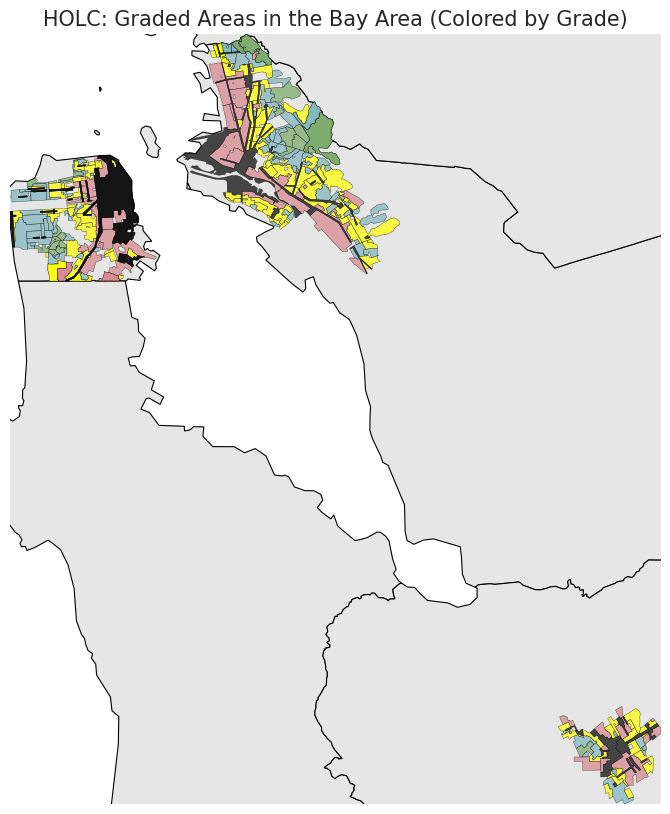

In [14]:
fig_name_grade_city = "2_holc_grade_by_city.png"
fig, ax = plt.subplots(figsize=(10, 10))

bay_outline.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="black",
    linewidth=0.8,
    alpha=1.0
)

holc.plot(
    ax=ax,
    color=holc["fill"],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

ax.set_xlim(holc.total_bounds[0], holc.total_bounds[2])
ax.set_ylim(holc.total_bounds[1], holc.total_bounds[3])

ax.set_title("HOLC: Graded Areas in the Bay Area", fontsize=15)
ax.set_axis_off()

fig.savefig(fig_folder + fig_name_grade_city)
plt.show()

Let's take a closer look for each of the cities.

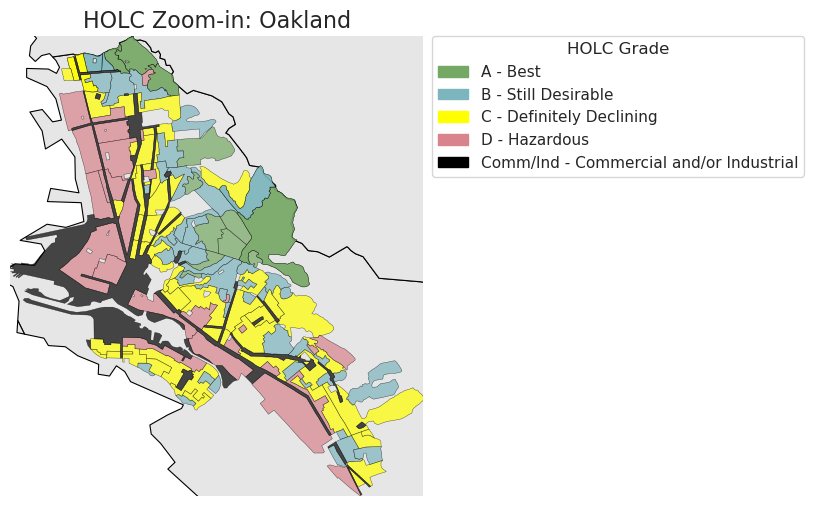

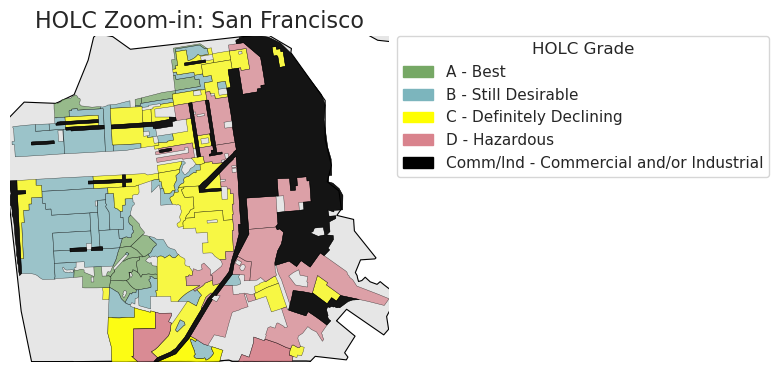

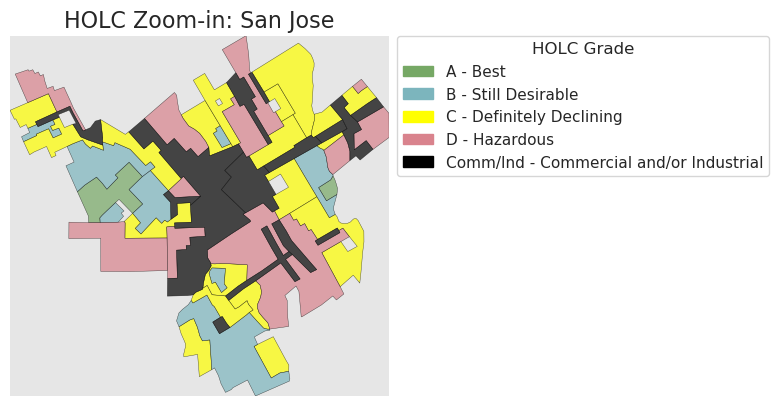

In [21]:
# List of unique HOLC cities
cities = holc["city"].unique()

for city in cities:

    fig_unique_city = f"3_unique_map_{city}.png"
    
    holc_city = holc[holc["city"] == city]

    fig, ax = plt.subplots(figsize=(8, 8))

    # bay area outline
    bay_outline.plot(
        ax=ax,
        color="#e6e6e6",
        edgecolor="black",
        linewidth=0.8,
        alpha=1.0
    )

    # just like before, plot the city and fill by grade
    holc_city.plot(
        ax=ax,
        color=holc_city["fill"],
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3
    )

    # zoom into city
    bounds = holc_city.total_bounds
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])

    # format and legend
    legend_handles = []
    for grade, color in grade_color_map.items():
        patch = mpatches.Patch(color=color, label=f"{grade}")
        legend_handles.append(patch)

    ax.legend(
        handles=legend_handles,
        title="HOLC Grade",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0
    )

    ax.set_title(f"HOLC Zoom-in: {city}", fontsize=16)
    ax.set_axis_off()

    fig.savefig(fig_folder + fig_unique_city, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

From the previous figure we can observe how the D (Hazardous, red) and C (Definitely declining, yellow) areas are surrounding the commercial and industrial areas (black), and how the A/B graded areas are not as spread out as the other grades, they are mainly concentrated in certain sections of the cities. Also notice how it seems the the A/B areas are less in each city, relative to C/D or even commercial and/or industrial in the case of San José. 

Let's see now the proportion of HOLC grades by city, considering the total graded areas per city how many of those are in each grade or are commercial and/or industrial. As we can see, only in the case of San José this difference might be really evident, however to actually be able to conclude anything, we would have to carry out tests to prove our hypothesis.

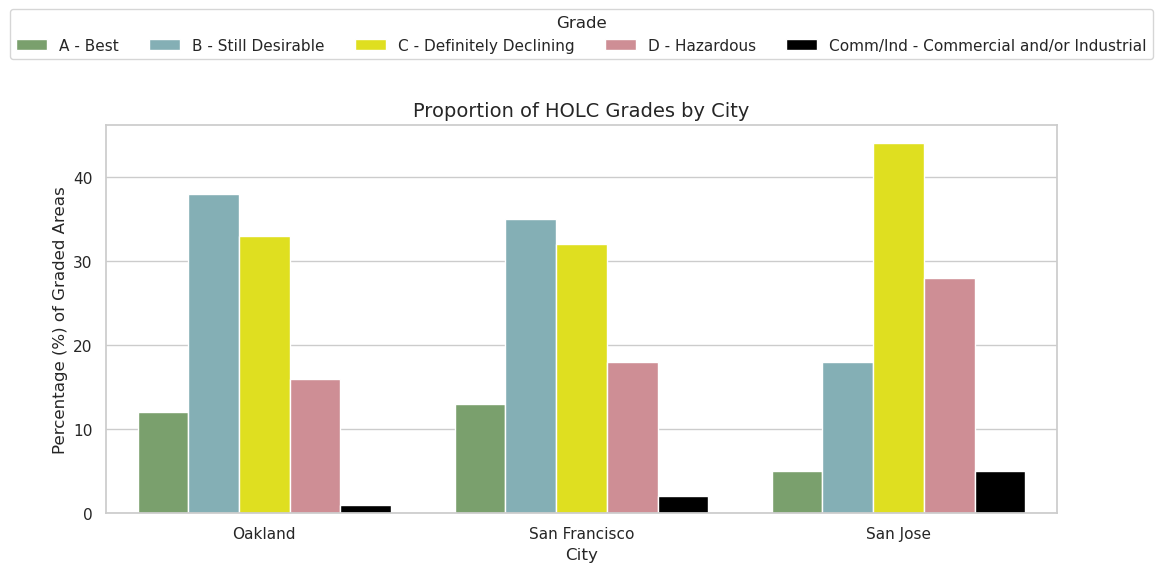

In [19]:
fig_name_prop_bars = "4_proportion_grades_city.png"

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=grade_counts,
    x="city",
    y="relative_count",
    hue="grade_category",
    palette=grade_color_map,
    hue_order=grade_color_map.keys()
)

plt.legend(title="Grade",loc='lower center',
           bbox_to_anchor=(0.5, 1.15), 
           ncol=5)
plt.title("Proportion of HOLC Grades by City", fontsize=14)
plt.xlabel("City")
plt.ylabel("Percentage (%) of Graded Areas")
plt.tight_layout()
fig.savefig(fig_folder + fig_name_prop_bars)
plt.show()

Lastly, we are going to compare areas between grades, even though the proportion of graded polygons show us some information, it is also worth noting that the areas between polygons aren't equal, since HOLC was not a systematic and studied process, but rather subjective following discrimination more than anything else. 

*As an important note*: the total area doesn't add up to 100% exactly, it is usually over a 100%, because of different historical reasons like overlap, the transition from physical to digital media, and the somewhat artisanal mapping, more prone to mistakes and how geographic limits have changed throughout the past few years.

We can see how, for San Francisco, for example, the commercial and/or industrial areas are in proportion the lesser ones out of all of the categories, in terms of area, San Francisco's commercial and industrial area is the highest out of all categories.

We can also observe how the areas grow as the grade decreases, sometimes exchangably for D and C, but it is always the case that A and B grades have less total area.


In [17]:
agg_area = (
    holc.groupby(["city", "grade","grade_category"])["area_km2"]
        .sum()
        .reset_index()
)

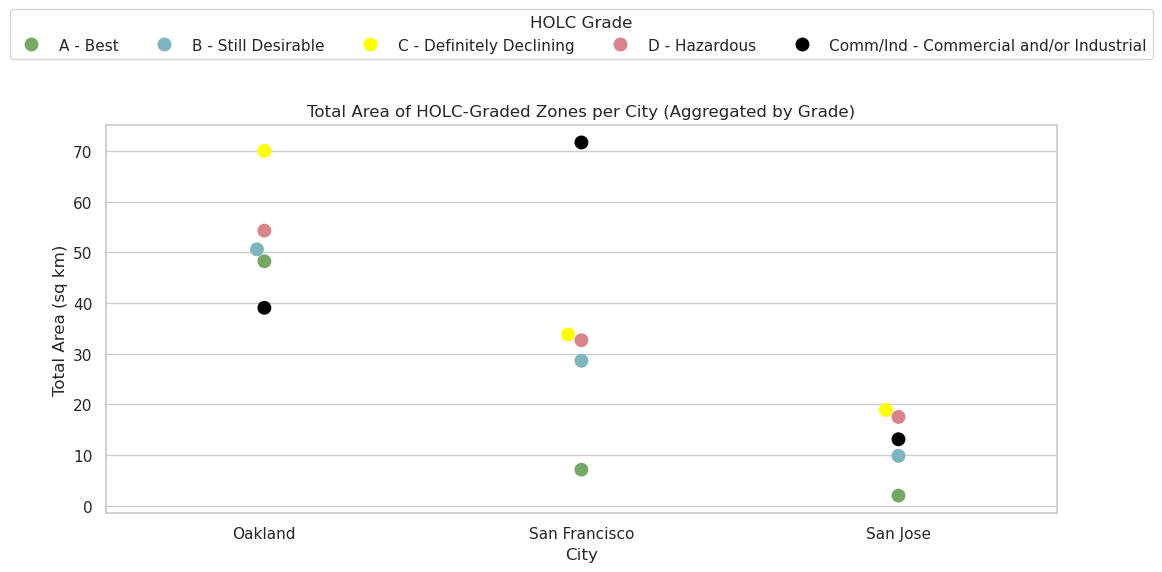

In [20]:
fig_name_areas = "5_areas_per_grade.png"
fig, ax = plt.subplots(figsize=(12, 6))

sns.swarmplot(
    data=agg_area,
    x="city",
    y="area_km2",
    hue="grade_category",
    hue_order=grade_color_map.keys(),
    palette=grade_color_map,
    size=10
)

plt.title("Total Area (sq km) of HOLC-Graded Zones per City")
plt.xlabel("City")
plt.ylabel("Total Area (sq km)")
plt.legend(title="HOLC Grade",
           loc='lower center',
           bbox_to_anchor=(0.5, 1.15), 
           ncol=5)

plt.tight_layout()
fig.savefig(fig_folder + fig_name_areas)
plt.show()